# "THE PRICE IS RIGHT" Capstone Project

This week - build a model that predicts how much something costs from a description, based on a scrape of Amazon data


A model that can estimate how much something costs, from its description.

# Order of play

DAY 1: Data Curation  
DAY 2: Data Pre-processing  
DAY 3: Evaluation, Baselines, Traditional ML  
DAY 4: Deep Learning and LLMs  
DAY 5: Fine-tuning a Frontier Model  

## DAY 4: Neural Networks and LLMs

Today we'll work from Traditional ML to Neural Networks to Large Language Models!!

In [1]:
# imports

import os
from dotenv import load_dotenv
from huggingface_hub import login
from pricer.evaluator import evaluate
from litellm import completion
from pricer.items import Item
import numpy as np
from tqdm.notebook import tqdm
import csv
from sklearn.feature_extraction.text import HashingVectorizer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import CosineAnnealingLR


In [3]:
LITE_MODE = True

load_dotenv(override=True)
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
username = "ed-donner"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_lite"

train, val, test = Item.from_hub(dataset)

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

README.md:   0%|          | 0.00/735 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/6.07M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/304k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/304k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loaded 20,000 training items, 1,000 validation items, 1,000 test items


# Before we look at the Artificial Neural Networks

## There is a different kind of Neural Network we could consider

In [ ]:
# Write the test set to a CSV

with open('human_in.csv', 'w', encoding="utf-8") as csvfile:
    writer = csv.writer(csvfile)
    for t in test[:100]:
        writer.writerow([t.summary, 0])

In [ ]:
# Read it back in

human_predictions = []
with open('human_out.csv', 'r', encoding="utf-8") as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        human_predictions.append(float(row[1]))

In [ ]:
def human_pricer(item):
    idx = test.index(item)
    return human_predictions[idx]

In [ ]:
human = human_pricer(test[0])
actual = test[0].price
print(f"Human predicted {human} for an item that actually costs {actual}")


In [ ]:
evaluate(human_pricer, test, size=100)

# And now - a vanilla Neural Network

During the remainder of this course we will get deeper into how Neural Networks work, and how to train a neural network.

This is just a sneak preview - let's make our own Neural Network, from scratch, using Pytorch.

Use this to get intuition; it's not important to know all about Neural networks at this point..

In [5]:
# Prepare our documents and prices

y = np.array([float(item.price) for item in train])
documents = [item.summary for item in train]

In [6]:
# Use the HashingVectorizer for a Bag of Words model
# Using binary=True with the CountVectorizer makes "one-hot vectors"

np.random.seed(42)
vectorizer = HashingVectorizer(n_features=5000, stop_words='english', binary=True)
X = vectorizer.fit_transform(documents)

In [7]:
# Define the neural network - here is Pytorch code to create a 8 layer neural network

class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_size, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 64)
        self.layer4 = nn.Linear(64, 64)
        self.layer5 = nn.Linear(64, 64)
        self.layer6 = nn.Linear(64, 64)
        self.layer7 = nn.Linear(64, 64)
        self.layer8 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        output1 = self.relu(self.layer1(x))
        output2 = self.relu(self.layer2(output1))
        output3 = self.relu(self.layer3(output2))
        output4 = self.relu(self.layer4(output3))
        output5 = self.relu(self.layer5(output4))
        output6 = self.relu(self.layer6(output5))
        output7 = self.relu(self.layer7(output6))
        output8 = self.layer8(output7)
        return output8

In [8]:
# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X.toarray())
y_train_tensor = torch.FloatTensor(y).unsqueeze(1)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_tensor, y_train_tensor, test_size=0.01, random_state=42)

# Create the loader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Initialize the model
input_size = X_train_tensor.shape[1]
model = NeuralNetwork(input_size)

In [9]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Number of trainable parameters: {trainable_params:,}")

Number of trainable parameters: 669,249


In [13]:
# Define loss function and optimizer

loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# We will do 2 complete runs through the data

EPOCHS = 2

for epoch in range(EPOCHS):
    model.train()
    for batch_X, batch_y in tqdm(train_loader):
        optimizer.zero_grad()

        # The next 4 lines are the 4 stages of training: forward pass, loss calculation, backward pass, optimize
        
        outputs = model(batch_X)
        loss = loss_function(outputs, batch_y)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = loss_function(val_outputs, y_val)

    print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {loss.item():.3f}, Val Loss: {val_loss.item():.3f}')

  0%|          | 0/310 [00:00<?, ?it/s]

Epoch [1/2], Train Loss: 13157.505, Val Loss: 17024.512


  0%|          | 0/310 [00:00<?, ?it/s]

Epoch [2/2], Train Loss: 6093.645, Val Loss: 17623.695


In [14]:
def neural_network(item):
    model.eval()
    with torch.no_grad():
        vector = vectorizer.transform([item.summary])
        vector = torch.FloatTensor(vector.toarray())
        result = model(vector)[0].item()
    return max(0, result)

  0%|          | 0/200 [00:00<?, ?it/s]

$102 $58 $21 $1 $23 $175 $1 $8 $9 $220 $287 $209 $41 $310 $13 $1 $12 $8 $105 $60 $76 $27 $76 $31 $289 $302 $348 $38 $36 $38 $28 $142 $45 $30 $82 $64 $41 $62 $103 $48 $162 $10 $36 $78 $119 $61 $56 $46 $45 $66 $11 $61 $144 $43 $107 $63 $34 $112 $0 $29 $75 $1 $32 $6 $404 $108 $34 $192 $29 $238 $13 $20 $151 $42 $25 $33 $92 $51 $17 $19 $81 $86 $21 $40 $17 $49 $56 $146 $67 $150 $14 $31 $8 $1 $43 $80 $2 $70 $152 $86 $42 $59 $8 $73 $2 $39 $77 $342 $16 $19 $37 $51 $80 $21 $80 $120 $219 $43 $72 $14 $12 $236 $52 $13 $99 $33 $24 $136 $58 $77 $0 $58 $90 $19 $53 $38 $103 $67 $68 $117 $31 $172 $7 $232 $193 $61 $29 $361 $139 $1 $6 $88 $4 $62 $3 $155 $122 $4 $89 $5 $118 $0 $13 $17 $373 $4 $112 $32 $9 $31 $16 $26 $190 $4 $12 $2 $27 $38 $35 $46 $393 $8 $173 $78 $10 $48 $73 $35 $4 $8 $77 $6 $9 $32 $6 $71 $112 $9 $5 $3 

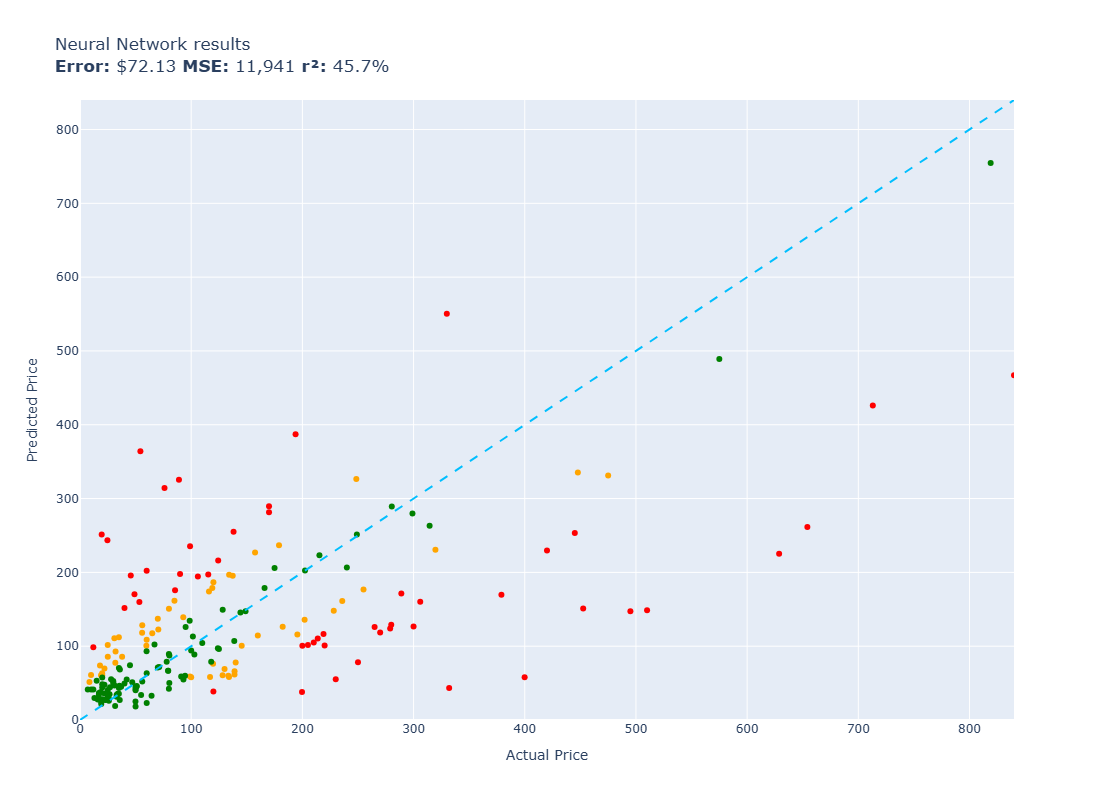

In [15]:
evaluate(neural_network, test)

# And now - to the frontier!

Let's see how Frontier models do out of the box; no training, just inference based on their world knowledge.

Tomorrow we will do some training.

In [16]:
def messages_for(item):
    message = f"Estimate the price of this product. Respond with the price, no explanation\n\n{item.summary}"
    return [{"role": "user", "content": message}]

In [17]:
print(test[0].summary)

Title: Excess V2 Distortion/Modulation Pedal  
Category: Music Pedals  
Brand: Old Blood Noise  
Description: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  
Details: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.


In [18]:
messages_for(test[0])

[{'role': 'user',
  'content': 'Estimate the price of this product. Respond with the price, no explanation\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.'}]

In [19]:
# The function for gpt-4.1-nano

def gpt_4__1_nano(item):
    response = completion(model="openai/gpt-4.1-nano", messages=messages_for(item))
    return response.choices[0].message.content

In [20]:
gpt_4__1_nano(test[0])

'$250'

In [21]:
test[0].price

219.0

  0%|          | 0/200 [00:00<?, ?it/s]

$39 $34 $25 $20 $45 $80 $6 $65 $1 $870 $213 $71 $20 $9 $1 $8 $71 $5 $40 $1 $54 $26 $65 $25 $182 $273 $705 $5 $401 $60 $10 $15 $10 $50 $35 $119 $60 $21 $36 $13 $165 $45 $20 $5 $70 $0 $17 $13 $85 $52 $25 $105 $175 $10 $197 $16 $8 $10 $52 $3 $86 $2 $51 $40 $229 $30 $90 $295 $25 $74 $16 $8 $30 $4 $10 $21 $126 $5 $8 $3 $30 $3 $15 $74 $11 $0 $32 $56 $0 $1 $3 $20 $5 $20 $2 $78 $9 $193 $20 $375 $20 $33 $11 $11 $150 $32 $10 $370 $6 $99 $20 $136 $29 $43 $54 $80 $0 $5 $4 $47 $34 $411 $50 $84 $50 $10 $5 $151 $21 $94 $209 $13 $65 $0 $85 $0 $55 $0 $78 $62 $36 $0 $70 $8 $134 $118 $15 $140 $15 $13 $4 $144 $2 $10 $1 $29 $71 $36 $20 $15 $211 $17 $8 $2 $340 $3 $752 $30 $10 $5 $0 $3 $20 $8 $18 $101 $3 $37 $6 $43 $346 $25 $150 $1 $30 $3 $73 $17 $10 $2 $0 $99 $15 $11 $20 $70 $10 $30 $21 $1 

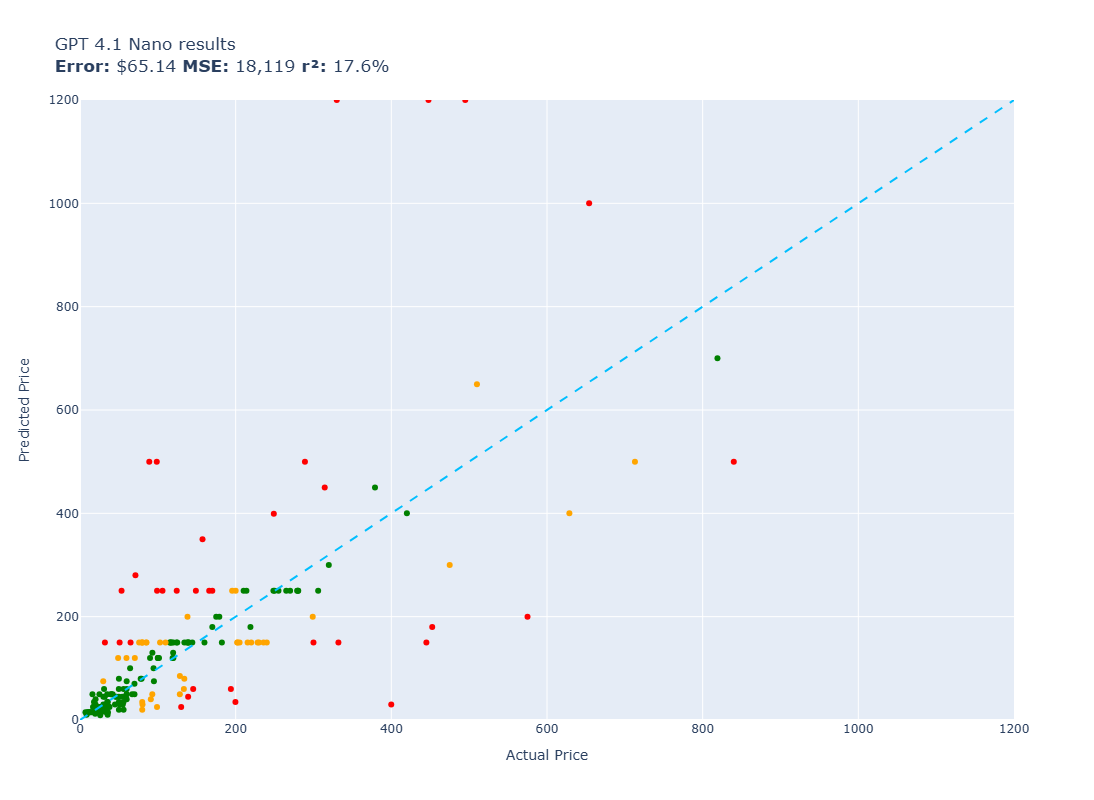

In [22]:
evaluate(gpt_4__1_nano, test)

In [23]:
def claude_opus_4_5(item):
    response = completion(model="anthropic/claude-opus-4-5", messages=messages_for(item))
    return response.choices[0].message.content

In [24]:
evaluate(claude_opus_4_5, test)

  0%|          | 0/200 [00:00<?, ?it/s]

AuthenticationError: litellm.AuthenticationError: Missing Anthropic API Key - A call is being made to anthropic but no key is set either in the environment variables or via params. Please set `ANTHROPIC_API_KEY` in your environment vars

In [25]:
def gemini_3_pro_preview(item):
    response = completion(model="gemini/gemini-3-pro-preview", messages=messages_for(item), reasoning_effort='low')
    return response.choices[0].message.content

In [26]:
evaluate(gemini_3_pro_preview, test, size=50, workers=2)

  0%|          | 0/50 [00:00<?, ?it/s]


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.



RateLimitError: litellm.RateLimitError: litellm.RateLimitError: geminiException - {
  "error": {
    "code": 429,
    "message": "You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-3-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-3-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3-pro\nPlease retry in 2.822620796s.",
    "status": "RESOURCE_EXHAUSTED",
    "details": [
 

In [ ]:
def gemini_2__5_flash_lite(item):
    response = completion(model="gemini/gemini-2.5-flash-lite", messages=messages_for(item))
    return response.choices[0].message.content

In [ ]:
evaluate(gemini_2__5_flash_lite, test)

In [ ]:

def grok_4__1_fast(item):
    response = completion(model="xai/grok-4-1-fast-non-reasoning", messages=messages_for(item), seed=42)
    return response.choices[0].message.content

In [ ]:
evaluate(grok_4__1_fast, test)

In [ ]:
# The function for gpt-5.1

def gpt_5__1(item):
    response = completion(model="gpt-5.1", messages=messages_for(item), reasoning_effort='high', seed=42)
    return response.choices[0].message.content


In [ ]:
evaluate(gpt_5__1, test)